# 00. Machine setup and validation

**Run this before anything else, and do not skip it.**

Everything downstream in this workflow inherits whatever is wrong here. If the
mesh loads differently than you expect, or the solver settings are wrong for
your machine, you will still get numbers. They will look completely normal in a
table. They will be wrong, and nothing will tell you.

This notebook is the check that catches that, for the price of one solve
instead of a whole dataset.

## What it checks

There are two kinds of check, and the distinction matters if you are pointing
this workflow at your own tokamak.

**Machine-agnostic checks.** These work for any machine, because they compare
the solver against itself:

1. The mesh loads and reports the geometry you expect
2. The coil sets are found
3. The solve converges
4. The achieved plasma matches the shape that was requested

**Published-reference checks.** These need someone to have published an answer
for your machine, which is not always true. Where they exist they are stronger,
because they catch errors that are self-consistent but still wrong.

For CUTE the published reference is the mesh statistics printed in the Open
Fusion Toolkit's own `CUTE_null_ex` example. For SPARC there is a full
published discharge to compare against.

## Changing machines

Everything below reads from the `MACHINE` config block. To run this for a
different tokamak, add an entry there and change one line.

## Setup

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np

# Notebooks have no __file__, so anchor paths on the working directory instead.
REPO_ROOT = os.path.abspath("..")
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.meshing import load_gs_mesh
from OpenFUSIONToolkit.TokaMaker.util import create_isoflux, create_power_flux_fun

## The machine configuration

This is the only cell you edit to change machines.

`mesh_stats` is the published answer key where one exists. Leave it as `None`
for a machine that has no published reference, and the notebook will skip that
check rather than inventing one.

In [2]:
MACHINES = {
    "cute": {
        "mesh": "data/CUTE_mesh.h5",
        "lim_zmax": 0.38,
        "F0": 0.17,                  # R0 * B0 [T.m]
        "coil_bound_A": 1.0e3,       # CUTE coils: 1 kA per turn
        # Requested reference plasma
        "Ip": 200.0e3,
        "R0": 0.32, "Z0": 0.0, "a": 0.17, "kappa": 1.7, "delta": 0.4,
        "x_points": [[0.22, -0.33], [0.20, 0.34]],
        "init_a": 0.13,
        # Published answer key: mesh statistics from the OFT CUTE_null_ex
        # example's stored output. Not an equilibrium reference, but it proves
        # we loaded the same geometry the toolkit authors did.
        "mesh_stats": {
            "area": 1.301, "points": 5796, "edges": 17283, "cells": 11488,
        },
    },
}

MACHINE = "cute"
cfg = MACHINES[MACHINE]
print(f"Machine: {MACHINE}")
for k, v in cfg.items():
    if k != "mesh_stats":
        print(f"  {k:14s} {v}")

Machine: cute
  mesh           data/CUTE_mesh.h5
  lim_zmax       0.38
  F0             0.17
  coil_bound_A   1000.0
  Ip             200000.0
  R0             0.32
  Z0             0.0
  a              0.17
  kappa          1.7
  delta          0.4
  x_points       [[0.22, -0.33], [0.2, 0.34]]
  init_a         0.13


## Load the mesh

The mesh carries the vacuum vessel, the coil sets, and the region tags the
solver needs. Watch the statistics the toolkit prints as it loads: those
numbers are the first thing we check.

In [3]:
myOFT = OFT_env(nthreads=2)
mygs = TokaMaker(myOFT)

mesh_pts, mesh_lc, mesh_reg, coil_dict, cond_dict = load_gs_mesh(
    os.path.join(REPO_ROOT, cfg["mesh"])
)
mygs.setup_mesh(mesh_pts, mesh_lc, mesh_reg)
mygs.setup_regions(cond_dict=cond_dict, coil_dict=coil_dict)
mygs.settings.lim_zmax = cfg["lim_zmax"]
mygs.settings.pm = False
mygs.setup(order=2, F0=cfg["F0"])

#----------------------------------------------
Open FUSION Toolkit Initialized
Development branch:    main
Revision id:           b19540a
Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    2
Fortran input file    = /var/folders/dp/643386y10pg0wlcjl4xc3s7m0000gp/T/oft_53731/oftpyin
XML input file        = none
Integer Precisions    =    4   8
Float Precisions      =    4   8  16
Complex Precisions    =    4   8
LA backend            = native
#----------------------------------------------


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  1.301E+00
    # of points  =    5796
    # of edges   =   17283
    # of cells   =   11488
    # of boundary points =     102
    # of boundary edges  =     102
    # of boundary cells  =     102
  Resolution statistics:
    hmin =  3.994E-03
    hrms =  1.721E-02
    hmax =  7.410E-02
  Surface grounded at vertex     761


**** Creati

### Check 1: does the mesh match the published geometry?

The mesh file could be the wrong version, or truncated, or a different machine
entirely. Comparing the point, edge and cell counts against the published
values catches all of that immediately.

This is the cheapest check in the whole workflow and it is worth having.

In [4]:
checks = []   # (name, passed, detail) accumulated through the notebook

n_points = mesh_pts.shape[0]
n_cells = mesh_lc.shape[0]
print(f"Loaded mesh: {n_points} points, {n_cells} cells, "
      f"{len(mygs.coil_sets)} coil sets")

ref = cfg.get("mesh_stats")
if ref is None:
    print("\nNo published mesh statistics for this machine, skipping.")
    checks.append(("mesh matches published geometry", None, "no reference"))
else:
    ok_pts = n_points == ref["points"]
    ok_cells = n_cells == ref["cells"]
    print(f"\n  points: {n_points} vs published {ref['points']}  "
          f"{'ok' if ok_pts else 'MISMATCH'}")
    print(f"  cells:  {n_cells} vs published {ref['cells']}  "
          f"{'ok' if ok_cells else 'MISMATCH'}")
    checks.append(("mesh matches published geometry", ok_pts and ok_cells,
                   f"{n_points} points, {n_cells} cells"))

Loaded mesh: 5796 points, 11488 cells, 28 coil sets

  points: 5796 vs published 5796  ok
  cells:  11488 vs published 11488  ok


### Check 2: are the coils there?

A mesh with no coil sets cannot be used for a free-boundary solve at all, and
the failure downstream would be confusing rather than obvious.

In [5]:
coil_names = sorted(mygs.coil_sets.keys())
print(f"{len(coil_names)} coil sets: {', '.join(coil_names[:8])}"
      f"{' ...' if len(coil_names) > 8 else ''}")

checks.append(("coil sets present", len(coil_names) > 0,
               f"{len(coil_names)} sets"))

28 coil sets: CS01, CS02, CS03, CS04, CS05, CS06, CS07, CS08 ...


## Configure the solve

Three things get set here, and each one is a modelling choice rather than a
fact about the machine:

- **Coil limits.** For CUTE, 1 kA per turn.
- **Regularization.** Many different coil-current combinations produce almost
  the same plasma, so the solver needs a preference to pick one. These terms
  say "prefer small currents, and prefer up-down symmetry".
- **Profiles.** The pressure and current shapes, which Grad-Shafranov takes as
  inputs rather than working out for itself.

Change any of these and you get a different, also-valid answer. That is worth
remembering when comparing against anyone else's solve.

In [6]:
mygs.set_coil_bounds({k: [-cfg["coil_bound_A"], cfg["coil_bound_A"]]
                      for k in mygs.coil_sets})

# Up-down mirror pairs, so the solver prefers symmetric solutions.
coil_mirrors = {f"CS{2*i+1:02d}": f"CS{2*i+2:02d}" for i in range(7)}
coil_mirrors.update({f"PF{i:02d}": f"PF{15-i:02d}" for i in range(1, 8)})
disable_list = ["PF01"]

reg_terms = []
for name in mygs.coil_sets:
    if name not in coil_mirrors:
        continue
    if name in disable_list:
        # Held out of the shaping solution with a heavy penalty.
        reg_terms.append(mygs.coil_reg_term({name: 1.0}, target=0.0, weight=1.0e5))
        reg_terms.append(mygs.coil_reg_term({coil_mirrors[name]: 1.0},
                                            target=0.0, weight=1.0e5))
    else:
        reg_terms.append(mygs.coil_reg_term({name: 1.0}, target=0.0, weight=1.0e-1))
        reg_terms.append(mygs.coil_reg_term({name: 1.0, coil_mirrors[name]: -1.0},
                                            target=0.0, weight=1.0e0))
mygs.set_coil_reg(reg_terms=reg_terms)

mygs.set_profiles(ffp_prof=create_power_flux_fun(40, 1.5, 2.0),
                  pp_prof=create_power_flux_fun(40, 4.0, 1.0))
print("coil bounds, regularization and profiles set")

coil bounds, regularization and profiles set


## Ask for a plasma and solve

The isoflux points describe the boundary shape we want. The saddle points mark
where the X-points should be. `set_targets` fixes the plasma current, and
`init_psi` gives the non-linear solver somewhere to start.

Note what we are doing: **requesting** a shape. The solver will return
something close to it, not exactly it, and the difference is the next check.

In [7]:
isoflux_pts = create_isoflux(80, cfg["R0"], cfg["Z0"], cfg["a"],
                             cfg["kappa"], cfg["delta"])
isoflux_pts = isoflux_pts[isoflux_pts[:, 0] > cfg["R0"] - cfg["a"] + 0.02, :]
isoflux_pts = np.vstack((isoflux_pts,
                         np.array([[cfg["R0"] - cfg["a"] - 0.02, cfg["Z0"]]])))

x_points = np.array(cfg["x_points"])
mygs.set_saddles(x_points)
mygs.set_isoflux(np.vstack((isoflux_pts, x_points)))

beta_approx = 0.2
mygs.set_targets(Ip=cfg["Ip"], Ip_ratio=(1.0 / beta_approx - 1.0))
mygs.init_psi(cfg["R0"], cfg["Z0"], cfg["init_a"], cfg["kappa"], cfg["delta"])

### Check 3: did it converge?

**A trap worth knowing about.** In the current Open Fusion Toolkit release,
`solve()` returns `None` on success and raises `ValueError` on failure. Older
code returned an integer error flag, so you will see examples written as

```python
err_flag = mygs.solve()
if err_flag == 0:
    print("converged")
```

Against the current release that check reports failure on every successful
solve, because `None != 0`. Catch the exception instead.

In [8]:
try:
    mygs.solve()
    converged = True
    detail = "solve() returned without raising"
except ValueError as exc:
    converged = False
    detail = str(exc)

print("converged" if converged else f"FAILED: {detail}")
checks.append(("solve converged", converged, detail))

converged


### Check 4: did we get the plasma we asked for?

**This is the check that works on any machine**, which makes it the important
one for a workflow meant to be reused.

We requested a shape. The solver returned an equilibrium. Comparing what we
asked for against what we got tests the whole setup at once: constraints,
regularization, profiles, coil limits. If the achieved plasma is nowhere near
the request, something in the configuration is wrong even if nothing errored.

Tolerances are loose on purpose. The solver is balancing shape constraints
against coil limits and regularization, so it is not supposed to hit the
request exactly. We are checking it landed in the right neighbourhood, not that
it obeyed.

In [9]:
stats = mygs.get_stats()

# The key names are q_0, q_95 and l_i. Getting these wrong is easy and silent:
# stats.get("q95") returns None and prints as "N/A" rather than raising.
requested_vs_achieved = [
    ("Ip [kA]",   cfg["Ip"] / 1e3,  stats["Ip"] / 1e3,      0.10),
    ("R_geo [m]", cfg["R0"],        stats["R_geo"],         0.15),
    ("a_geo [m]", cfg["a"],         stats["a_geo"],         0.25),
    ("kappa",     cfg["kappa"],     stats["kappa"],         0.25),
    ("delta",     cfg["delta"],     stats["delta"],         0.50),
]

print(f"{'quantity':<12}{'requested':>11}{'achieved':>11}{'rel. diff':>11}   verdict")
shape_ok = True
for name, req, got, tol in requested_vs_achieved:
    rel = abs(got - req) / max(abs(req), 1e-12)
    ok = rel <= tol
    shape_ok &= ok
    print(f"{name:<12}{req:>11.3f}{got:>11.3f}{rel:>10.1%}   "
          f"{'ok' if ok else 'OUT OF RANGE'}")

checks.append(("achieved plasma matches request", shape_ok, ""))

quantity      requested   achieved  rel. diff   verdict
Ip [kA]         200.000    199.991      0.0%   ok
R_geo [m]         0.320      0.309      3.4%   ok
a_geo [m]         0.170      0.183      7.4%   ok
kappa             1.700      1.751      3.0%   ok
delta             0.400      0.466     16.5%   ok


## The equilibrium itself

Everything that follows in this workflow is built on this solve, so it is worth
looking at it once.

Reference values for this configuration, useful when you change something and
want to know whether you broke it:

In [10]:
print(f"  Ip          = {stats['Ip'] / 1e3:8.1f} kA")
print(f"  R_geo       = {stats['R_geo']:8.4f} m")
print(f"  a_geo       = {stats['a_geo']:8.4f} m")
print(f"  kappa       = {stats['kappa']:8.3f}")
print(f"  delta       = {stats['delta']:8.3f}")
print(f"  q_0         = {abs(stats['q_0']):8.3f}")
print(f"  q_95        = {abs(stats['q_95']):8.3f}")
print(f"  l_i         = {stats['l_i']:8.3f}")
print(f"  beta_pol    = {stats['beta_pol']:8.3f}")
print(f"  volume      = {stats['vol']:8.4f} m^3")
print(f"  magnetic axis (R, Z) = ({mygs.o_point[0]:.4f}, {mygs.o_point[1]:.4f})")
print(f"  psi_bounds  = [{mygs.psi_bounds[0]:.5f}, {mygs.psi_bounds[1]:.5f}] Wb/rad")

  Ip          =    200.0 kA
  R_geo       =   0.3090 m
  a_geo       =   0.1827 m
  kappa       =    1.751
  delta       =    0.466
  q_0         =    0.911
  q_95        =    4.419
  l_i         =    1.251
  beta_pol    =   28.964
  volume      =   0.3059 m^3
  magnetic axis (R, Z) = (0.3340, 0.0002)
  psi_bounds  = [0.00131, 0.01108] Wb/rad


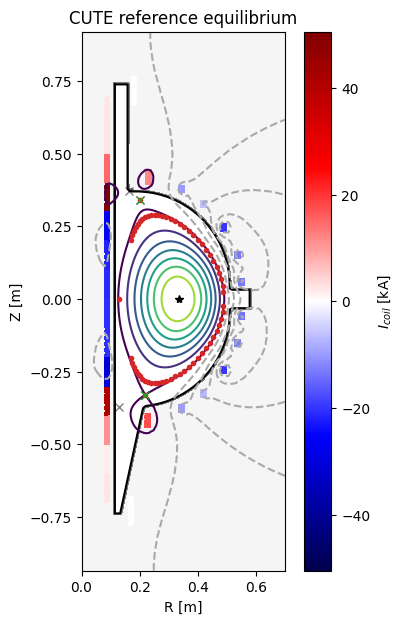

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(5, 7))
mygs.plot_machine(fig, ax, coil_colormap="seismic", coil_symmap=True,
                  coil_scale=1.0e-3, coil_clabel=r"$I_{coil}$ [kA]")
mygs.plot_psi(fig, ax, xpoint_color="k", vacuum_nlevels=6, plasma_nlevels=8)
mygs.plot_constraints(fig, ax, isoflux_color="tab:red", isoflux_marker=".")
ax.set_title(f"{MACHINE.upper()} reference equilibrium")
ax.set_xlabel("R [m]")
ax.set_ylabel("Z [m]")
plt.show()

## Result

In [12]:
print(f"{'check':<38}{'result'}")
print("-" * 52)
n_pass = n_fail = n_skip = 0
for name, ok, detail in checks:
    if ok is None:
        verdict, n_skip = "skipped (no reference)", n_skip + 1
    elif ok:
        verdict, n_pass = "PASS", n_pass + 1
    else:
        verdict, n_fail = "FAIL", n_fail + 1
    print(f"{name:<38}{verdict}")
print("-" * 52)
print(f"{n_pass} passed, {n_fail} failed, {n_skip} skipped")

if n_fail:
    print("\nDo not continue to notebook 01 until these pass.")
else:
    print("\nSetup is sound. Continue to 01_synthetic_diagnostics.")

check                                 result
----------------------------------------------------
mesh matches published geometry       PASS
coil sets present                     PASS
solve converged                       PASS
achieved plasma matches request       PASS
----------------------------------------------------
4 passed, 0 failed, 0 skipped

Setup is sound. Continue to 01_synthetic_diagnostics.


## What this does and does not prove

**Proves:** the mesh is the one you think it is, the solver runs, and the
configuration produces a plasma close to what was asked for.

**Does not prove:**

- That the *profiles* are right for your machine. Grad-Shafranov takes pressure
  and current shapes as inputs, and this notebook uses generic power-law
  profiles. A different choice gives a different, equally converged answer.
- That the setup works across the whole range of shapes you will sample later.
  One equilibrium is one point. Notebook 02 samples many, and some will fail.
- That the coil currents are right. Many current combinations produce nearly
  the same plasma, so matching a plasma does not mean matching currents.

For CUTE there is no published reference discharge to compare against, only
published mesh statistics. That is a real limitation of this notebook and worth
saying out loud: the plasma checks here are self-consistency checks, not
comparisons against an independent answer.

Where a machine does have a published discharge, comparing against it is
strictly stronger, because a setup can be perfectly self-consistent and still
wrong.